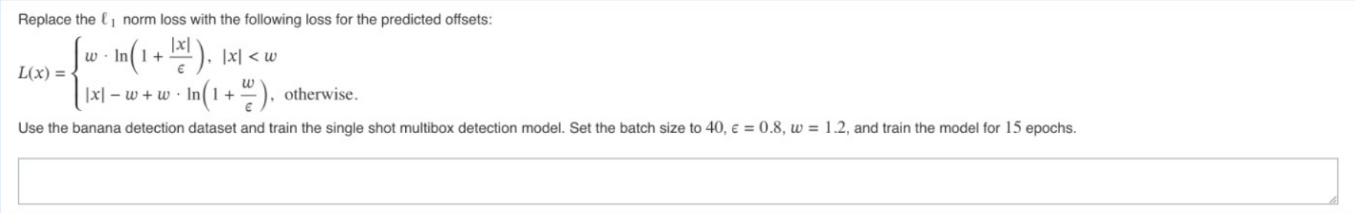

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt
import pandas as pd
import os
import requests
import zipfile

torch.manual_seed(42);

class L1Loss(nn.Module):
    def __init__(self, epsilon=0.8, omega=1.2):
        super().__init__()
        self.epsilon = epsilon
        self.omega = omega
    def forward(self, pred, target):
        x = torch.abs(pred - target)
        loss=torch.where(x<self.w,
                         self.w*torch.log(1+x/self.epsilon),
                         x-self.w+self.w*torch.log(1+self.w/self.epsilon))
        return loss

cls_loss = nn.CrossEntropyLoss(reduction='none')
bbox_loss = L1Loss(epsilon=0.8,omega = 1.2)


def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def read_data_bananas(is_train=True):
    """Read the banana detection dataset images and labels."""
    data_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/banana-detection.zip')
    csv_fname = os.path.join(data_dir, 'bananas_train' if is_train
                             else 'bananas_val', 'label.csv')
    csv_data = pd.read_csv(csv_fname)
    csv_data = csv_data.set_index('img_name')
    images, targets = [], []
    for img_name, target in csv_data.iterrows():
        images.append(torchvision.io.read_image(
            os.path.join(data_dir, 'bananas_train' if is_train else
                         'bananas_val', 'images', f'{img_name}')))
        # Here `target` contains (class, upper-left x, upper-left y,
        # lower-right x, lower-right y), where all the images have the same
        # banana class (index 0)
        targets.append(list(target))
    return images, torch.tensor(targets).unsqueeze(1) / 256

class BananasDataset(torch.utils.data.Dataset):
    """A customized dataset to load the banana detection dataset."""
    def __init__(self, is_train):
        self.features, self.labels = read_data_bananas(is_train)
        print('read ' + str(len(self.features)) + (f' training examples' if
              is_train else f' validation examples'))

    def __getitem__(self, idx):
        return (self.features[idx].float(), self.labels[idx])

    def __len__(self):
        return len(self.features)

def load_data_bananas(batch_size):
    """Load the banana detection dataset."""
    train_iter = torch.utils.data.DataLoader(BananasDataset(is_train=True),
                                             batch_size, shuffle=True)
    val_iter = torch.utils.data.DataLoader(BananasDataset(is_train=False),
                                           batch_size)
    return train_iter, val_iter

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    else:
        assert False, 'Only zip files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def cls_predictor(num_inputs, num_anchors, num_classes):
    return nn.Conv2d(num_inputs, num_anchors * (num_classes + 1),
                     kernel_size=3, padding=1)


def bbox_predictor(num_inputs, num_anchors):
    return nn.Conv2d(num_inputs, num_anchors * 4, kernel_size=3, padding=1)

def forward(x, block):
    return block(x)

Y1 = forward(torch.zeros((2, 8, 20, 20)), cls_predictor(8, 5, 10))
Y2 = forward(torch.zeros((2, 16, 10, 10)), cls_predictor(16, 3, 10))
Y1.shape, Y2.shape

def flatten_pred(pred):
    return torch.flatten(pred.permute(0, 2, 3, 1), start_dim=1)

def concat_preds(preds):
    return torch.cat([flatten_pred(p) for p in preds], dim=1)

concat_preds([Y1, Y2]).shape

def down_sample_blk(in_channels, out_channels):
    blk = []
    for _ in range(2):
        blk.append(nn.Conv2d(in_channels, out_channels,
                             kernel_size=3, padding=1))
        blk.append(nn.BatchNorm2d(out_channels))
        blk.append(nn.ReLU())
        in_channels = out_channels
    blk.append(nn.MaxPool2d(2))
    return nn.Sequential(*blk)


forward(torch.zeros((2, 3, 20, 20)), down_sample_blk(3, 10)).shape


def base_net():
    blk = []
    num_filters = [3, 16, 32, 64]
    for i in range(len(num_filters) - 1):
        blk.append(down_sample_blk(num_filters[i], num_filters[i+1]))
    return nn.Sequential(*blk)

forward(torch.zeros((2, 3, 256, 256)), base_net()).shape
def offset_boxes(anchors, assigned_bb, eps=1e-6):
    """Transform for anchor box offsets."""
    c_anc = box_corner_to_center(anchors)
    c_assigned_bb = box_corner_to_center(assigned_bb)
    offset_xy = 10 * (c_assigned_bb[:, :2] - c_anc[:, :2]) / c_anc[:, 2:]
    offset_wh = 5 * torch.log(eps + c_assigned_bb[:, 2:] / c_anc[:, 2:])
    offset = torch.cat([offset_xy, offset_wh], axis=1)
    return offset

def box_iou(boxes1, boxes2):
    """Compute pairwise IoU across two lists of anchor or bounding boxes."""
    box_area = lambda boxes: ((boxes[:, 2] - boxes[:, 0]) *
                              (boxes[:, 3] - boxes[:, 1]))
    # Shape of `boxes1`, `boxes2`, `areas1`, `areas2`: (no. of boxes1, 4),
    # (no. of boxes2, 4), (no. of boxes1,), (no. of boxes2,)
    areas1 = box_area(boxes1)
    areas2 = box_area(boxes2)
    # Shape of `inter_upperlefts`, `inter_lowerrights`, `inters`: (no. of
    # boxes1, no. of boxes2, 2)
    inter_upperlefts = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    inter_lowerrights = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    inters = (inter_lowerrights - inter_upperlefts).clamp(min=0)
    # Shape of `inter_areas` and `union_areas`: (no. of boxes1, no. of boxes2)
    inter_areas = inters[:, :, 0] * inters[:, :, 1]
    union_areas = areas1[:, None] + areas2 - inter_areas
    return inter_areas / union_areas

def assign_anchor_to_bbox(ground_truth, anchors, device, iou_threshold=0.5):
    """Assign closest ground-truth bounding boxes to anchor boxes."""
    num_anchors, num_gt_boxes = anchors.shape[0], ground_truth.shape[0]
    # Element x_ij in the i-th row and j-th column is the IoU of the anchor
    # box i and the ground-truth bounding box j
    jaccard = box_iou(anchors, ground_truth)
    # Initialize the tensor to hold the assigned ground-truth bounding box for
    # each anchor
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long,
                                  device=device)
    # Assign ground-truth bounding boxes according to the threshold
    max_ious, indices = torch.max(jaccard, dim=1)
    anc_i = torch.nonzero(max_ious >= iou_threshold).reshape(-1)
    box_j = indices[max_ious >= iou_threshold]
    anchors_bbox_map[anc_i] = box_j
    col_discard = torch.full((num_anchors,), -1)
    row_discard = torch.full((num_gt_boxes,), -1)
    for _ in range(num_gt_boxes):
        max_idx = torch.argmax(jaccard)  # Find the largest IoU
        box_idx = (max_idx % num_gt_boxes).long()
        anc_idx = (max_idx / num_gt_boxes).long()
        anchors_bbox_map[anc_idx] = box_idx
        jaccard[:, box_idx] = col_discard
        jaccard[anc_idx, :] = row_discard
    return anchors_bbox_map

def multibox_target(anchors, labels):
    """Label anchor boxes using ground-truth bounding boxes."""
    batch_size, anchors = labels.shape[0], anchors.squeeze(0)
    batch_offset, batch_mask, batch_class_labels = [], [], []
    device, num_anchors = anchors.device, anchors.shape[0]
    for i in range(batch_size):
        label = labels[i, :, :]
        anchors_bbox_map = assign_anchor_to_bbox(
            label[:, 1:], anchors, device)
        bbox_mask = ((anchors_bbox_map >= 0).float().unsqueeze(-1)).repeat(
            1, 4)
        # Initialize class labels and assigned bounding box coordinates with
        # zeros
        class_labels = torch.zeros(num_anchors, dtype=torch.long,
                                   device=device)
        assigned_bb = torch.zeros((num_anchors, 4), dtype=torch.float32,
                                  device=device)
        # Label classes of anchor boxes using their assigned ground-truth
        # bounding boxes. If an anchor box is not assigned any, we label its
        # class as background (the value remains zero)
        indices_true = torch.nonzero(anchors_bbox_map >= 0)
        bb_idx = anchors_bbox_map[indices_true]
        class_labels[indices_true] = label[bb_idx, 0].long() + 1
        assigned_bb[indices_true] = label[bb_idx, 1:]
        # Offset transformation
        offset = offset_boxes(anchors, assigned_bb) * bbox_mask
        batch_offset.append(offset.reshape(-1))
        batch_mask.append(bbox_mask.reshape(-1))
        batch_class_labels.append(class_labels)
    bbox_offset = torch.stack(batch_offset)
    bbox_mask = torch.stack(batch_mask)
    class_labels = torch.stack(batch_class_labels)
    return (bbox_offset, bbox_mask, class_labels)

def get_blk(i):
    if i == 0:
        blk = base_net()
    elif i == 1:
        blk = down_sample_blk(64, 128)
    elif i == 4:
        blk = nn.AdaptiveMaxPool2d((1,1))
    else:
        blk = down_sample_blk(128, 128)
    return blk
def box_corner_to_center(boxes):
    """Convert from (upper-left, lower-right) to (center, width, height)."""
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = x2 - x1
    h = y2 - y1
    boxes = torch.stack((cx, cy, w, h), axis=-1)
    return boxes

def box_center_to_corner(boxes):
    """Convert from (center, width, height) to (upper-left, lower-right)."""
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    boxes = torch.stack((x1, y1, x2, y2), axis=-1)
    return boxes

def multibox_prior(data, sizes, ratios):
    """Generate anchor boxes with different shapes centered on each pixel."""
    in_height, in_width = data.shape[-2:]
    device, num_sizes, num_ratios = data.device, len(sizes), len(ratios)
    boxes_per_pixel = (num_sizes + num_ratios - 1)
    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor = torch.tensor(ratios, device=device)
    # Offsets are required to move the anchor to the center of a pixel. Since
    # a pixel has height=1 and width=1, we choose to offset our centers by 0.5
    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0 / in_height  # Scaled steps in y axis
    steps_w = 1.0 / in_width  # Scaled steps in x axis

    # Generate all center points for the anchor boxes
    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing='ij')
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)

    # Generate `boxes_per_pixel` number of heights and widths that are later
    # used to create anchor box corner coordinates (xmin, xmax, ymin, ymax)
    w = torch.cat((size_tensor * torch.sqrt(ratio_tensor[0]),
                   sizes[0] * torch.sqrt(ratio_tensor[1:])))\
                   * in_height / in_width  # Handle rectangular inputs
    h = torch.cat((size_tensor / torch.sqrt(ratio_tensor[0]),
                   sizes[0] / torch.sqrt(ratio_tensor[1:])))
    # Divide by 2 to get half height and half width
    anchor_manipulations = torch.stack((-w, -h, w, h)).T.repeat(
                                        in_height * in_width, 1) / 2

    # Each center point will have `boxes_per_pixel` number of anchor boxes, so
    # generate a grid of all anchor box centers with `boxes_per_pixel` repeats
    out_grid = torch.stack([shift_x, shift_y, shift_x, shift_y],
                dim=1).repeat_interleave(boxes_per_pixel, dim=0)
    output = out_grid + anchor_manipulations
    return output.unsqueeze(0)
def blk_forward(X, blk, size, ratio, cls_predictor, bbox_predictor):
    Y = blk(X)
    anchors = multibox_prior(Y, sizes=size, ratios=ratio)
    cls_preds = cls_predictor(Y)
    bbox_preds = bbox_predictor(Y)
    return (Y, anchors, cls_preds, bbox_preds)


sizes = [[0.2, 0.272], [0.37, 0.447], [0.54, 0.619], [0.71, 0.79],
         [0.88, 0.961]]
ratios = [[1, 2, 0.5]] * 5
num_anchors = len(sizes[0]) + len(ratios[0]) - 1


class TinySSD(nn.Module):
    def __init__(self, num_classes, **kwargs):
        super(TinySSD, self).__init__(**kwargs)
        self.num_classes = num_classes
        idx_to_in_channels = [64, 128, 128, 128, 128]
        for i in range(5):
            # Equivalent to the assignment statement `self.blk_i = get_blk(i)`
            setattr(self, f'blk_{i}', get_blk(i))
            setattr(self, f'cls_{i}', cls_predictor(idx_to_in_channels[i],
                                                    num_anchors, num_classes))
            setattr(self, f'bbox_{i}', bbox_predictor(idx_to_in_channels[i],
                                                      num_anchors))

    def forward(self, X):
        anchors, cls_preds, bbox_preds = [None] * 5, [None] * 5, [None] * 5
        for i in range(5):
            # Here `getattr(self, 'blk_%d' % i)` accesses `self.blk_i`
            X, anchors[i], cls_preds[i], bbox_preds[i] = blk_forward(
                X, getattr(self, f'blk_{i}'), sizes[i], ratios[i],
                getattr(self, f'cls_{i}'), getattr(self, f'bbox_{i}'))
        anchors = torch.cat(anchors, dim=1)
        cls_preds = concat_preds(cls_preds)
        cls_preds = cls_preds.reshape(
            cls_preds.shape[0], -1, self.num_classes + 1)
        bbox_preds = concat_preds(bbox_preds)
        return anchors, cls_preds, bbox_preds


net = TinySSD(num_classes=1)
X = torch.zeros((32, 3, 256, 256))
anchors, cls_preds, bbox_preds = net(X)

print('output anchors:', anchors.shape)
print('output class preds:', cls_preds.shape)
print('output bbox preds:', bbox_preds.shape)

batch_size = 40
train_iter, _ = load_data_bananas(batch_size)

device, net = try_gpu(), TinySSD(num_classes=1)
trainer = torch.optim.SGD(net.parameters(), lr=0.2, weight_decay=5e-4)

cls_loss = nn.CrossEntropyLoss(reduction='none')
bbox_loss = nn.L1Loss(reduction='none')

def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks):
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    cls = cls_loss(cls_preds.reshape(-1, num_classes),
                   cls_labels.reshape(-1)).reshape(batch_size, -1).mean(dim=1)
    bbox = bbox_loss(bbox_preds * bbox_masks,
                     bbox_labels * bbox_masks).mean(dim=1)
    return cls + bbox
def cls_eval(cls_preds, cls_labels):
    # Because the class prediction results are on the final dimension,
    # `argmax` needs to specify this dimension
    return float((cls_preds.argmax(dim=-1).type(
        cls_labels.dtype) == cls_labels).sum())

def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())

def train(net, train_iter, num_epochs, device):
  cls_acc_all = []
  bbox_mae_all = []
  net = net.to(device)
  for epoch in range(num_epochs):
    # Sum of training accuracy, no. of examples in sum of training accuracy,
    # Sum of absolute error, no. of examples in sum of absolute error
    total_cls = 0
    total_cls_labels = 0
    total_bbox = 0
    total_bbox_labels = 0
    net.train()
    for features, target in train_iter:
        trainer.zero_grad()
        X, Y = features.to(device), target.to(device)
        # Generate multiscale anchor boxes and predict their classes and
        # offsets
        anchors, cls_preds, bbox_preds = net(X)
        # Label the classes and offsets of these anchor boxes
        bbox_labels, bbox_masks, cls_labels = multibox_target(anchors, Y)
        # Calculate the loss function using the predicted and labeled values
        # of the classes and offsets
        l = calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels,
                      bbox_masks)
        l.mean().backward()
        trainer.step()
        total_cls += cls_eval(cls_preds, cls_labels)
        total_cls_labels += cls_labels.numel()
        total_bbox += bbox_eval(bbox_preds, bbox_labels, bbox_masks)
        total_bbox_labels += bbox_labels.numel()
    cls_acc, bbox_mae = total_cls / total_cls_labels * 100, total_bbox / total_bbox_labels
    cls_acc_all.append(cls_acc)
    bbox_mae_all.append(bbox_mae)
    print(f'Epoch {epoch + 1}, Class accuracy {cls_acc:.2f}, Bounding box MAE {bbox_mae:.2e}')

  return cls_acc_all, bbox_mae_all

num_epochs = 15
cls_acc_all, bbox_mae_all = train(net, train_iter, num_epochs, device) #2 min

output anchors: torch.Size([1, 5444, 4])
output class preds: torch.Size([32, 5444, 2])
output bbox preds: torch.Size([32, 21776])
read 1000 training examples
read 100 validation examples
Epoch 1, Class accuracy 97.27, Bounding box MAE 5.12e-03
Epoch 2, Class accuracy 99.51, Bounding box MAE 4.89e-03
Epoch 3, Class accuracy 99.51, Bounding box MAE 4.77e-03
Epoch 4, Class accuracy 99.51, Bounding box MAE 4.66e-03


KeyboardInterrupt: 

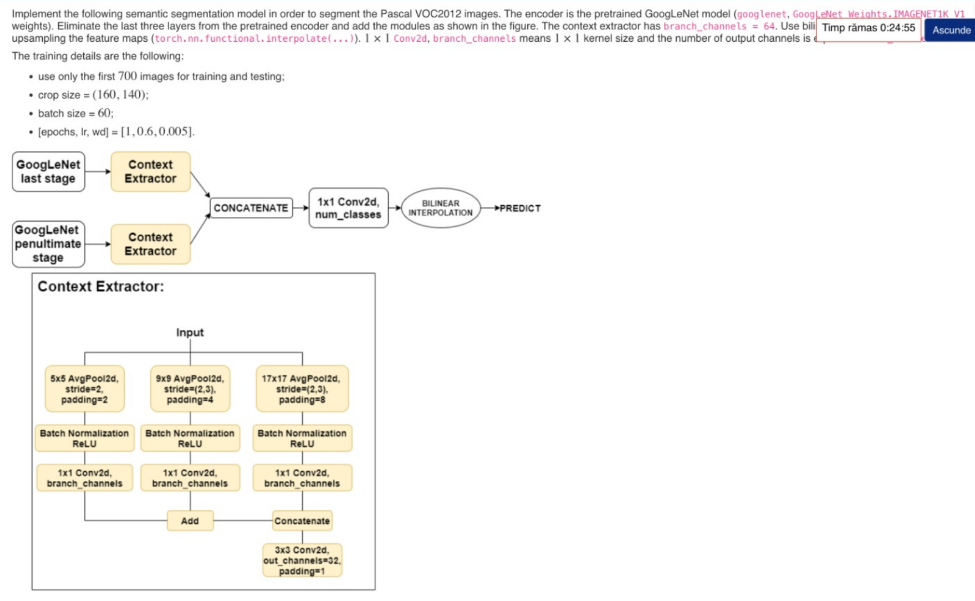

In [ ]:
pretrained_net = torchvision.models.googlenet(weights=torchvision.models.GoogLeNet_Weights.IMAGENET1K_V1) #Asta poti sa nu o faci,dar pe mine m-a ajutat
list(pretrained_net.children())[:-3]

[BasicConv2d(
   (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
   (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
 ),
 MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True),
 BasicConv2d(
   (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
   (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
 ),
 BasicConv2d(
   (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
   (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
 ),
 MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True),
 Inception(
   (branch1): BasicConv2d(
     (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
     (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
   )
   (branch2): Sequential(
     (0): BasicConv2d(
       (conv): 

In [2]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile


def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', 'VOCdevkit/VOC2012') #1 min

/tmp/ipython-input-3388839215.py:60: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  fp.extractall(base_dir)


In [1]:
def read_voc_images(voc_dir, is_train=True):
    """Read all VOC feature and label images."""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
    return features, labels

train_features, train_labels = read_voc_images(voc_dir, True)

n = 5
imgs = train_features[:n] + train_labels[:n]
imgs = [img.permute(1,2,0) for img in imgs]
show_images(imgs, 2, n);

VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']


def voc_colormap2label():
    """Build the mapping from RGB to class indices for VOC labels."""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

def voc_label_indices(colormap, colormap2label):
    """Map any RGB values in VOC labels to their class indices."""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

y = voc_label_indices(train_labels[0], voc_colormap2label())
y[105:115, 130:140], VOC_CLASSES[1]


def voc_rand_crop(feature, label, height, width):
    """Randomly crop both feature and label images."""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label


class VOCSegDataset(torch.utils.data.Dataset):
    """A customized dataset to load the VOC dataset."""

    def __init__(self, is_train, crop_size, voc_dir):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)


crop_size = (160, 180)
voc_train = VOCSegDataset(True, crop_size, voc_dir)
voc_test = VOCSegDataset(False, crop_size, voc_dir)

batch_size = 32
train_iter = torch.utils.data.DataLoader(voc_train, batch_size, shuffle=True,
                                    drop_last=True,
                                    num_workers=2)


def load_data_voc(batch_size, crop_size):
    """Load the VOC semantic segmentation dataset."""
    voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', os.path.join(
        'VOCdevkit', 'VOC2012'))
    num_workers = 2
    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter


def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight

NameError: name 'voc_dir' is not defined

In [ ]:
class ContextExtractor(nn.Module):
    def __init__(self, in_channels, branch_channels):
        super(ContextExtractor, self).__init__()

        self.conv1=nn.Sequential(nn.AvgPool2d(kernel_size=5,stride=2,padding=2),
                                 nn.BatchNorm2d(in_channels),
                                 nn.ReLU(),
                                 nn.Conv2d(in_channels,branch_channels,kernel_size=1))

        self.conv2=nn.Sequential(nn.AvgPool2d(kernel_size=9,stride=(2,3),padding=4),
                                 nn.BatchNorm2d(in_channels),
                                 nn.ReLU(),
                                 nn.Conv2d(in_channels,branch_channels,kernel_size=1))

        self.conv3=nn.Sequential(nn.AvgPool2d(kernel_size=17,stride=(2,3),padding=8),
                                 nn.BatchNorm2d(in_channels),
                                 nn.ReLU(),
                                 nn.Conv2d(in_channels,branch_channels,kernel_size=1))
        self.final_conv=nn.Conv2d(2*branch_channels, branch_channels, kernel_size=3, padding=1)
    def forward(self,x):
        c1=self.conv1(x)
        c2=self.conv2(x)
        c3=self.conv3(x)
        c4=c1+c2
        c5 = torch.cat([c4, c3], dim=1)

        out = self.final_conv(c5)
        return out



In [ ]:
class ExDubios(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        base=torchvision.models.googlenet(weights=torchvision.models.GoogLeNet_Weights.IMAGENET1K_V1)
        self.backbone = list(base.children())

        self.stage1 = nn.Sequential(*self.backbone[:13])
        self.stage2 = nn.Sequential(*self.backbone[13:-3])


        self.ce_pen = ContextExtractor(832, 64)
        self.ce_last = ContextExtractor(1024, 64)

        self.classifier = nn.Conv2d(128, num_classes, kernel_size=1)

    def forward(self, x):
        pen = self.stage1(x)        # Penultimate stage
        last = self.stage2(pen) # Last stage

        # 2. Aplicăm context extractor
        c_pen = self.ce_pen(pen)
        c_last = self.ce_last(last)

        # 3. Aliniem rezoluția (c_last e mai mic, îl mărim să fie ca c_pen)
        c_last = F.interpolate(c_last, size=c_pen.shape[-2:], mode='bilinear', align_corners=False)


        out = torch.cat([c_pen, c_last], dim=1)
        out = self.classifier(out)

        # 5. Mărim totul la dimensiunea pozei originale (Predict)
        return F.interpolate(out, size=x.shape[-2:], mode='bilinear', align_corners=False)

In [ ]:
batch_size, crop_size = 60, (160, 140)
train_iter, test_iter = load_data_voc(batch_size, crop_size) #1 min

/tmp/ipython-input-3388839215.py:60: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  fp.extractall(base_dir)


In [ ]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = torch.argmax(y_hat, axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()  # Set the model to evaluation mode
        if not device:
            device = next(iter(net.parameters())).device
    # No. of correct predictions, no. of predictions
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X = X.to(device)
            y = y.to(device)
            total_hits += accuracy(net(X), y)
            total_samples += y.numel()
    return total_hits / total_samples * 100

def train_batch(net, X, y, loss, trainer, device):
    X = X.to(device)
    y = y.to(device)
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = accuracy(pred, y)
    return train_loss_sum, train_acc_sum

def train(net, train_iter, test_iter, loss, trainer, num_epochs,
               device=try_gpu()):
    num_batches = len(train_iter)
    train_loss_all = []
    train_acc_all = []
    test_acc_all = []
    net = net.to(device)
    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples,
        # no. of predictions
        total_loss = 0
        total_acc = 0
        total_samples = 0
        total_predictions = 0
        for i, (features, labels) in enumerate(train_iter):
            l, acc = train_batch(
                net, features, labels, loss, trainer, device)
            total_loss += l
            total_acc += acc
            total_samples += labels.shape[0]
            total_predictions += labels.numel()
        train_loss_all.append(total_loss / total_samples)
        train_acc_all.append(total_acc / total_predictions * 100)
        test_acc = evaluate_accuracy(net, test_iter)
        test_acc_all.append(test_acc)
        print(f'loss {total_loss / total_samples:.3f}, train acc '
            f'{total_acc / total_predictions * 100:.3f}, test acc {test_acc:.3f}')
    return train_acc_all, test_acc_all

def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

In [ ]:
num_epochs, lr, wd, device = 1, 0.6, 0.005, try_gpu()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
train_acc_all, test_acc_all = train(net, train_iter, test_iter, loss, trainer, num_epochs, device) #6 min

In [ ]:
exit()

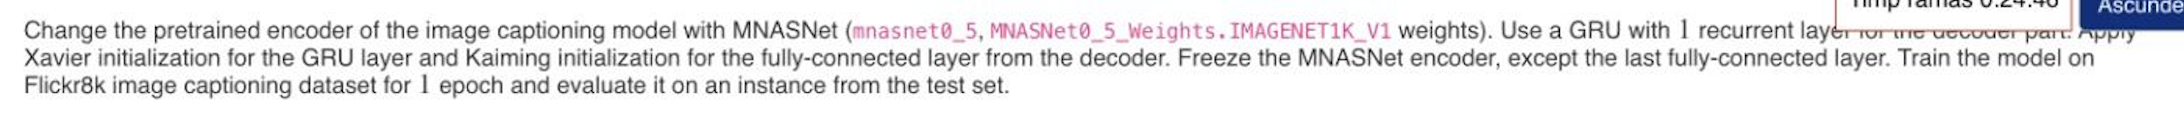

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torch.nn as nn
import torchvision.models as models
from torch.nn.utils.rnn import pad_sequence
from PIL import Image
import spacy
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url, cache_dir=".")
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    fp = zipfile.ZipFile(fname, 'r')
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip', 'Flickr8k_Dataset')
download_extract('https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip', 'Flickr8k_text')
spacy_en = spacy.load('en_core_web_sm')

In [ ]:
class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<BOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<BOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    def tokenizer_eng(self, text):
        return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4

        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                if word not in frequencies:
                    frequencies[word] = 1

                else:
                    frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]


def load_captions(path):
    captions_list = []
    image_captions = {}
    with open(path, "r") as file:
        for line in file.readlines():
            words = line.strip("\n").split()
            caption = ' '.join(words[1:])
            captions_list.append(caption)

    return captions_list


vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(load_captions("Flickr8k.token.txt"))

In [ ]:
def split_data(all_captions_path, img_list_path, name):
    img_names = []
    with open(img_list_path, "r") as file:
        for line in file.readlines():
            img_name = line.strip("\n").split(".")[0]
            img_names.append(img_name)

    lines = []
    with open(all_captions_path, "r") as file:
        for line in file.readlines():
            words = line.replace(";",",").strip("\n").split()
            img_name = words[0].split(".")[0]

            if img_name in img_names:
                new_line = img_name + ".jpg;" + " ".join(words[1:])
                lines.append(new_line)

    with open(name, "w") as file:
        file.writelines("image;caption\n")
        lines = map(lambda x:x + '\n', lines)
        file.writelines(lines)


split_data("Flickr8k.token.txt", "Flickr_8k.trainImages.txt", "train.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.devImages.txt", "validation.txt")
split_data("Flickr8k.token.txt", "Flickr_8k.testImages.txt", "test.txt")


class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, vocab, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file, sep=";")
        self.vocab = vocab
        self.transform = transform

        # Get img, caption columns
        self.imgs = self.df["image"]
        self.captions = self.df["caption"]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index]
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        numericalized_caption = [self.vocab.stoi["<BOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])

        return img, torch.tensor(numericalized_caption)



class CollateDataset:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=False, padding_value=self.pad_idx)

        return imgs, targets


def get_loader(
    root_folder,
    annotation_file,
    vocab,
    transform,
    batch_size=32,
    num_workers=2,
    shuffle=True,
    pin_memory=True,
):
    dataset = FlickrDataset(root_folder, annotation_file, vocab, transform=transform)

    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=CollateDataset(pad_idx=dataset.vocab.stoi["<PAD>"]),
    )

    return loader, dataset

transform = transforms.Compose(
        [transforms.Resize((299, 299)),
         transforms.ToTensor(),
         transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]),
         ]
    )

train_loader, train_dataset = get_loader(
    "Flicker8k_Dataset", "train.txt", vocab, transform=transform
)

val_loader, val_dataset = get_loader(
    "Flicker8k_Dataset", "validation.txt", vocab, transform=transform
)

test_loader, test_dataset = get_loader(
    "Flicker8k_Dataset", "test.txt", vocab, transform=transform, shuffle=False
)


class EncoderCNN(nn.Module):
    def __init__(self, embed_size, train_CNN=False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        self.mnasnet = models.mnasnet0_5(weights=models.MNASNet0_5_Weights.IMAGENET1K_V1)
        in_features= self.mnasnet.classifier[1].in_features

        self.mnasnet.classifier = nn.Sequential(
            nn.Dropout(p=0.2, inplace=True),
            nn.Linear(in_features, embed_size)
        )

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        features = self.mnasnet(images)
        return self.dropout(self.relu(features))



class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, num_layers)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)
        #aplica xavier pentru GRU
        for name, param in self.gru.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
        #aplica kaiming pentru stratul linear
        nn.init.kaiming_uniform_(self.linear.weight)

    def forward(self, features, captions):
        embeddings = self.dropout(self.embed(captions))
        _, states = self.gru(features.unsqueeze(0))
        hiddens, _ = self.gru(embeddings, states)
        outputs = self.linear(hiddens)
        return outputs




class CNNtoRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        self.encoderCNN = EncoderCNN(embed_size)
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        features = self.encoderCNN(images)
        outputs = self.decoderRNN(features, captions)
        return outputs

    def caption_image(self, image, vocabulary, max_length=40):
        result_caption = []

        with torch.no_grad():
            x = self.encoderCNN(image).unsqueeze(0)
            states = None

            for _ in range(max_length):
                hiddens, states = self.decoderRNN.lstm(x, states)
                output = self.decoderRNN.linear(hiddens.squeeze(0))
                predicted = output.argmax(0)
                result_caption.append(predicted.item())
                x = self.decoderRNN.embed(predicted).unsqueeze(0)

                if vocabulary.itos[predicted.item()] == "<EOS>":
                    break

        return [vocabulary.itos[idx] for idx in result_caption]


embed_size = 256
hidden_size = 256
vocab_size = len(vocab)
num_layers = 1
learning_rate = 3e-4
num_epochs = 1
device = try_gpu()
model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
loss_criterion = nn.CrossEntropyLoss(ignore_index=train_dataset.vocab.stoi["<PAD>"])


for name, param in model.encoderCNN.mnasnet.named_parameters():
        if "fc.weight" in name or "fc.bias" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False


train_loss = [] #5 min
dev_loss = []

for epoch in range(num_epochs):
    model.train()

    train_run_loss = []
    dev_run_loss = []
    index = 0

    for idx, (imgs, captions) in enumerate(train_loader):
        imgs = imgs.to(device)
        captions = captions.to(device)
        optimizer.zero_grad()
        outputs = model(imgs, captions)
        loss = loss_criterion(outputs.reshape(-1, outputs.shape[2]), captions.reshape(-1))
        loss.backward()
        optimizer.step()
        train_run_loss.append(loss.item())
        if (index+1) % 100 == 0:
            print("[Train {}] Iteration {} | Running Loss: {}".format(epoch+1, index+1, round(np.mean(train_run_loss), 4)))
        index += 1

    avg_loss = np.mean(train_run_loss)
    train_loss.append(avg_loss)
    print("[Train] Epoch {} | Average Loss: {}".format(epoch+1, round(avg_loss, 4)))

    index = 0
    for idx, (imgs, captions) in enumerate(val_loader):
        with torch.no_grad():
            imgs = imgs.to(device)
            captions = captions.to(device)
            outputs = model(imgs, captions)
            loss = loss_criterion(outputs.reshape(-1, outputs.shape[2]), captions.reshape(-1))
            dev_run_loss.append(loss.item())
            index += 1

    avg_loss = np.mean(dev_run_loss)
    dev_loss.append(avg_loss)
    print("[Valid] Epoch {} | Average Loss: {}".format(epoch+1, round(avg_loss, 4)))

In [ ]:
def print_example(model, device, loader, dataset):
    model.eval()
    img, caption = next(iter(loader))
    caption = caption.transpose(0, 1)
    plt.imshow(img[0].permute(1, 2, 0))
    print("Example CORRECT: " + " ".join([dataset.vocab.itos[idx] for idx in caption[0].tolist()
      if dataset.vocab.itos[idx] not in {"<PAD>", "<BOS>", "<EOS>"}]))
    print(
        "Example OUTPUT: "
        + " ".join(model.caption_image(img[0].unsqueeze(0).to(device), dataset.vocab))
    )

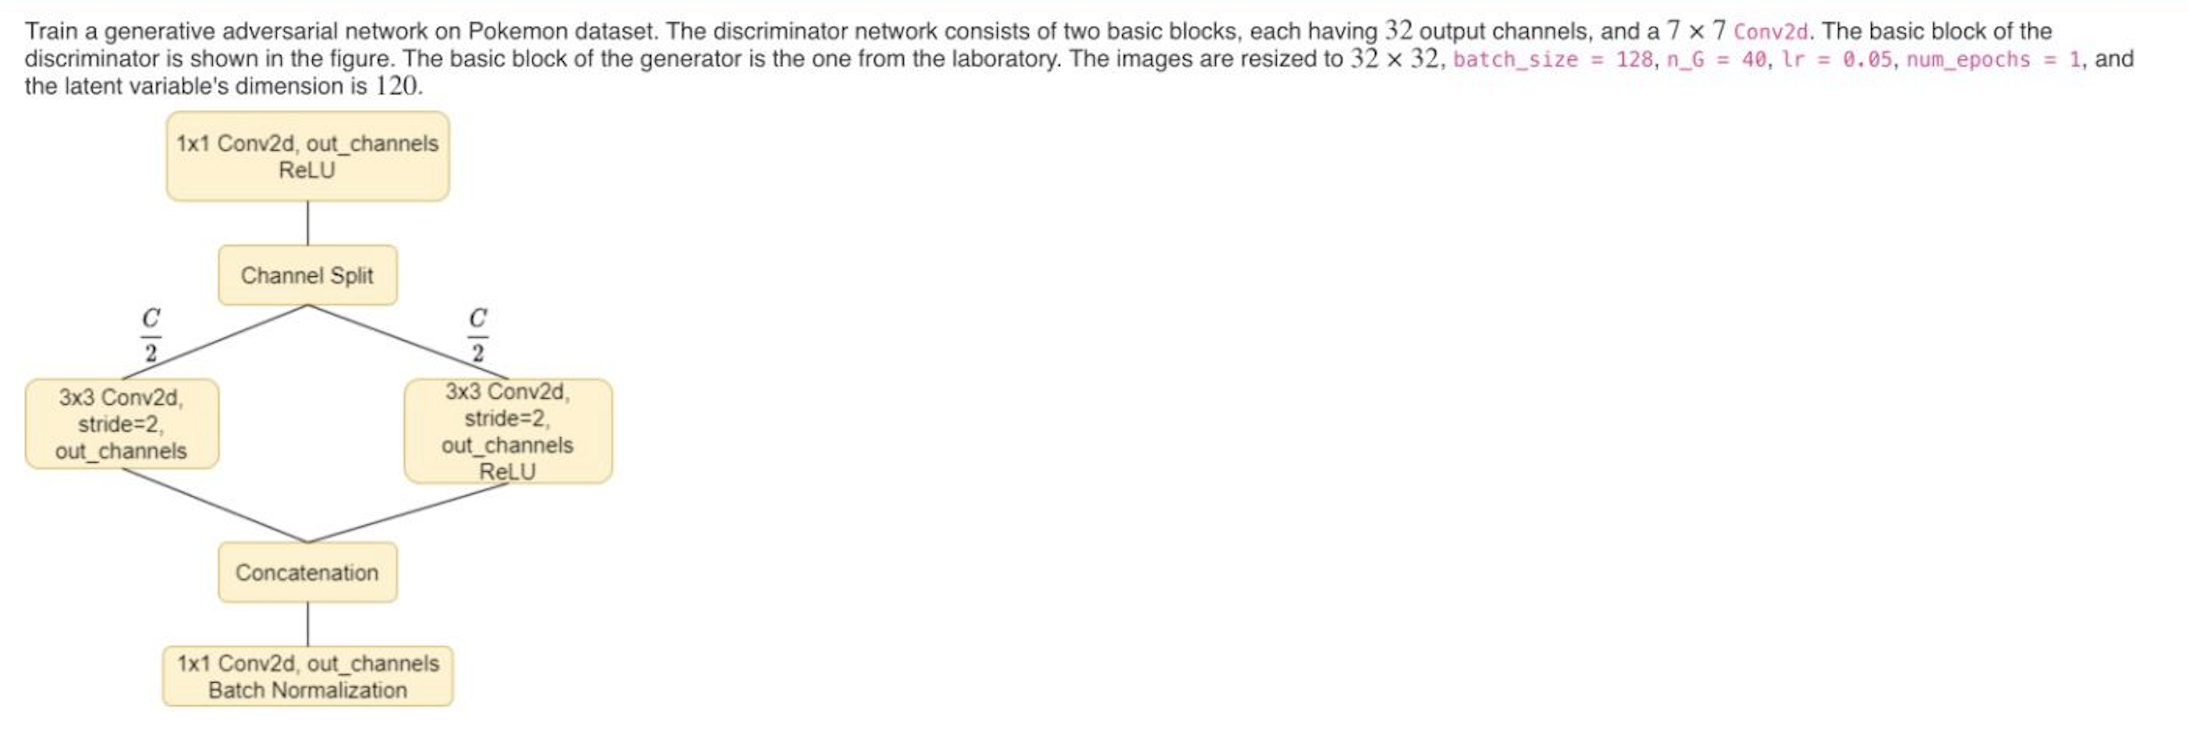

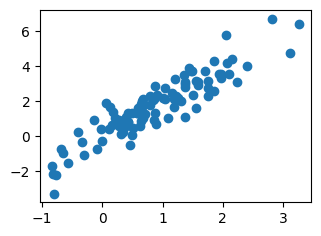

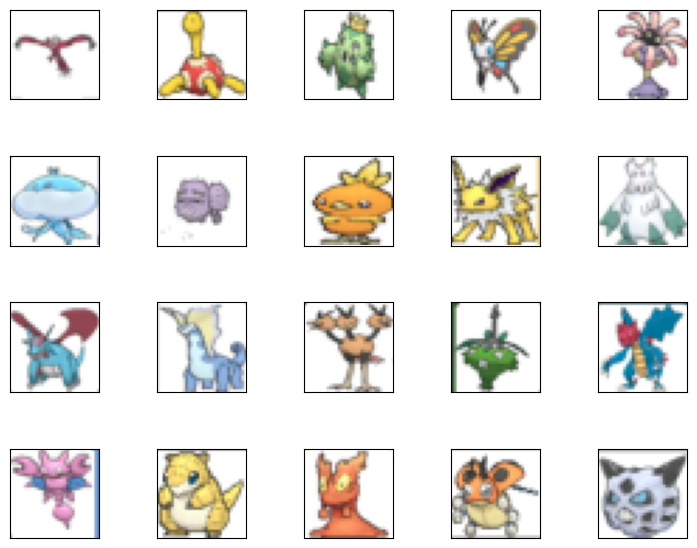

In [3]:
import torch
import torchvision
from torch import nn
from matplotlib import pyplot as plt
from IPython import display
import warnings
import os
import requests
import zipfile
import tarfile

X = torch.normal(0.0, 1, (1000, 2))
A = torch.tensor([[1, 2], [-0.1, 0.5]])
b = torch.tensor([1, 2])
data = torch.matmul(X, A) + b
def set_figsize(figsize=(3.5, 2.5)):
    """Set the figure size for matplotlib."""
    plt.rcParams['figure.figsize'] = figsize

set_figsize()
plt.scatter(data[:100, (0)].detach().numpy(), data[:100, (1)].detach().numpy());


def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 8
data_iter = load_array((data,), batch_size)

net_G = nn.Sequential(nn.Linear(2, 2))


net_D = nn.Sequential(
    nn.Linear(2, 5), nn.Tanh(),
    nn.Linear(5, 3), nn.Tanh(),
    nn.Linear(3, 1))


def update_D(X, Z, net_D, net_G, loss, trainer_D):
    batch_size = X.shape[0]
    ones = torch.ones((batch_size,), device=X.device)
    zeros = torch.zeros((batch_size,), device=X.device)

    trainer_D.zero_grad()

    # Adaugă .flatten() aici pentru a transforma [128, 1, 2, 2] în [128 * 1 * 2 * 2]
    # DAR, cel mai bine e să te asiguri că scoate exact batch_size.
    real_Y = net_D(X).reshape(batch_size, -1).mean(dim=1)
    fake_X = net_G(Z)
    fake_Y = net_D(fake_X.detach()).reshape(batch_size, -1).mean(dim=1)

    loss_D = (loss(real_Y, ones) + loss(fake_Y, zeros)) / 2
    loss_D.backward()
    trainer_D.step()
    return loss_D


def update_G(Z, net_D, net_G, loss, trainer_G):
    batch_size = Z.shape[0]
    ones = torch.ones((batch_size,), device=Z.device)

    trainer_G.zero_grad()
    fake_X = net_G(Z)
    # Aplică aceeași transformare și aici
    fake_Y = net_D(fake_X).reshape(batch_size, -1).mean(dim=1)

    loss_G = loss(fake_Y, ones)
    loss_G.backward()
    trainer_G.step()
    return loss_G

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Set the axes for matplotlib."""
    axes.set_xlabel(xlabel), axes.set_ylabel(ylabel)
    axes.set_xscale(xscale), axes.set_yscale(yscale)
    axes.set_xlim(xlim),     axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

class Animator:
    """For plotting data in animation."""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        """Defined in :numref:`sec_utils`"""
        # Incrementally plot multiple lines
        if legend is None:
            legend = []
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # Use a lambda function to capture arguments
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # Add multiple data points into the figure
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)



def train(net_D, net_G, data_iter, num_epochs, lr_D, lr_G, latent_dim, data):
    loss = nn.BCEWithLogitsLoss(reduction='sum')
    for w in net_D.parameters():
        nn.init.normal_(w, 0, 0.02)
    for w in net_G.parameters():
        nn.init.normal_(w, 0, 0.02)
    trainer_D = torch.optim.Adam(net_D.parameters(), lr=lr_D)
    trainer_G = torch.optim.Adam(net_G.parameters(), lr=lr_G)
    animator = Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs], nrows=2, figsize=(5, 5),
                            legend=['discriminator', 'generator'])
    animator.fig.subplots_adjust(hspace=0.3)
    D_loss = 0
    G_loss = 0
    total_examples = 0
    for epoch in range(num_epochs):
        # Train one epoch
        for (X,) in data_iter:
            batch_size = X.shape[0]
            Z = torch.normal(0, 1, size=(batch_size, latent_dim))
            D_loss += update_D(X, Z, net_D, net_G, loss, trainer_D)
            G_loss += update_G(Z, net_D, net_G, loss, trainer_G)
            total_examples += batch_size
        # Visualize generated examples
        Z = torch.normal(0, 1, size=(100, latent_dim))
        fake_X = net_G(Z).detach().numpy()
        animator.axes[1].cla()
        animator.axes[1].scatter(data[:, 0], data[:, 1])
        animator.axes[1].scatter(fake_X[:, 0], fake_X[:, 1])
        animator.axes[1].legend(['real', 'generated'])
        # Show the losses
        loss_D, loss_G = D_loss/total_examples, G_loss/total_examples
        animator.add(epoch + 1, (loss_D.cpu().detach().numpy(), loss_G.cpu().detach().numpy()))
    print(f'loss_D {loss_D:.3f}, loss_G {loss_G:.3f}, ')

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')


data_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/pokemon.zip', 'pokemon')
pokemon = torchvision.datasets.ImageFolder(data_dir)


batch_size = 128
transformer = torchvision.transforms.Compose([
    torchvision.transforms.Resize((32, 32)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)
])
pokemon.transform = transformer
data_iter = torch.utils.data.DataLoader(
    pokemon, batch_size=batch_size,
    shuffle=True, num_workers=2)


warnings.filterwarnings('ignore')
set_figsize((4, 4))
for X, y in data_iter:
    imgs = X[:20,:,:,:].permute(0, 2, 3, 1)/2+0.5
    show_images(imgs, num_rows=4, num_cols=5)
    break

class G_block(nn.Module):
    def __init__(self, out_channels, in_channels=3, kernel_size=4, strides=2,
                 padding=1, **kwargs):
        super(G_block, self).__init__(**kwargs)
        self.conv2d_trans = nn.ConvTranspose2d(in_channels, out_channels,
                                kernel_size, strides, padding, bias=False)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU()

    def forward(self, X):
        return self.activation(self.batch_norm(self.conv2d_trans(X)))


x = torch.zeros((2, 3, 16, 16))
g_blk = G_block(20)
g_blk(x).shape

x = torch.zeros((2, 3, 1, 1))
g_blk = G_block(20, strides=1, padding=0)
g_blk(x).shape

n_G = 40
net_G = nn.Sequential(
    G_block(in_channels=120, out_channels=n_G*4,
            strides=1, padding=0),                  # Output: (64 * 8, 4, 4)
    G_block(in_channels=n_G*4, out_channels=n_G*2), # Output: (64 * 4, 8, 8)
    G_block(in_channels=n_G*2, out_channels=n_G),   # Output: (64, 32, 32)
    nn.ConvTranspose2d(in_channels=n_G, out_channels=3,
                       kernel_size=4, stride=2, padding=1, bias=False),
    nn.Tanh())  # Output: (3, 64, 64)




In [4]:
def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """Plot data points."""

    def has_one_axis(X):  # True if X (tensor or list) has 1 axis
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X): X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)

    set_figsize(figsize)
    if axes is None:
        axes = plt.gca()
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        axes.plot(x,y,fmt) if len(x) else axes.plot(y,fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

In [5]:
class D_block(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(D_block, self).__init__()

        self.conv1=nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1),
            nn.ReLU()
        )

        self.branch_left=nn.Conv2d(out_channels//2,out_channels,kernel_size=3,stride=2,padding=1)
        self.branch_right=nn.Sequential(
            nn.Conv2d(out_channels//2,out_channels,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
        )

        self.final_conc=nn.Sequential(
            nn.Conv2d(out_channels*2,out_channels,kernel_size=1),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        x=self.conv1(x)
        c_half=x.shape[1]//2
        left=(x[:,:c_half,:,:])
        right=(x[:,c_half:,:,:])
        x_left=self.branch_left(left)
        x_right=self.branch_right(right)
        out=torch.cat((x_left,x_right),dim=1)
        out=self.final_conc(out)
        return out


net_D = nn.Sequential(
    D_block(in_channels=3, out_channels=32),
    D_block(in_channels=32, out_channels=32),
    nn.Conv2d(in_channels=32, out_channels=1,
              kernel_size=7))


def train(net_D, net_G, data_iter, num_epochs, lr, latent_dim,
          device=try_gpu()):
    loss = nn.BCEWithLogitsLoss(reduction='sum')
    for w in net_D.parameters():
        nn.init.normal_(w, 0, 0.02)
    for w in net_G.parameters():
        nn.init.normal_(w, 0, 0.02)
    net_D, net_G = net_D.to(device), net_G.to(device)
    trainer_hp = {'lr': lr, 'betas': [0.5,0.999]}
    trainer_D = torch.optim.Adam(net_D.parameters(), **trainer_hp)
    trainer_G = torch.optim.Adam(net_G.parameters(), **trainer_hp)
    animator = Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs], nrows=2, figsize=(5, 5),
                            legend=['discriminator', 'generator'])
    animator.fig.subplots_adjust(hspace=0.3)
    D_loss = 0
    G_loss = 0
    total_examples = 0
    for epoch in range(1, num_epochs + 1):
        # Train one epoch
        for X, _ in data_iter:
            batch_size = X.shape[0]
            Z = torch.normal(0, 1, size=(batch_size, latent_dim, 1, 1))
            X, Z = X.to(device), Z.to(device)
            D_loss += update_D(X, Z, net_D, net_G, loss, trainer_D)
            G_loss += update_G(Z, net_D, net_G, loss, trainer_G)
            total_examples += batch_size
        # Show generated examples
        Z = torch.normal(0, 1, size=(21, latent_dim, 1, 1), device=device)
        # Normalize the synthetic data to N(0, 1)
        fake_x = net_G(Z).permute(0, 2, 3, 1) / 2 + 0.5
        imgs = torch.cat(
            [torch.cat([
                fake_x[i * 7 + j].cpu().detach() for j in range(7)], dim=1)
             for i in range(len(fake_x)//7)], dim=0)
        animator.axes[1].cla()
        animator.axes[1].imshow(imgs)
        # Show the losses
        loss_D, loss_G = D_loss / total_examples, G_loss / total_examples
        animator.add(epoch, (loss_D.cpu().detach().numpy(), loss_G.cpu().detach().numpy()))
    print(f'loss_D {loss_D:.3f}, loss_G {loss_G:.3f}, ')



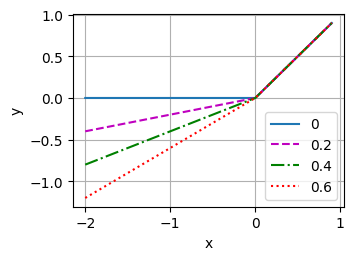

In [6]:
alphas = [0, .2, .4, .6, .8, 1]
x = torch.arange(-2, 1, 0.1)
Y = [nn.LeakyReLU(alpha)(x).detach().numpy() for alpha in alphas]
plot(x.detach().numpy(), Y, 'x', 'y', alphas)

loss_D 0.430, loss_G 6.788, 


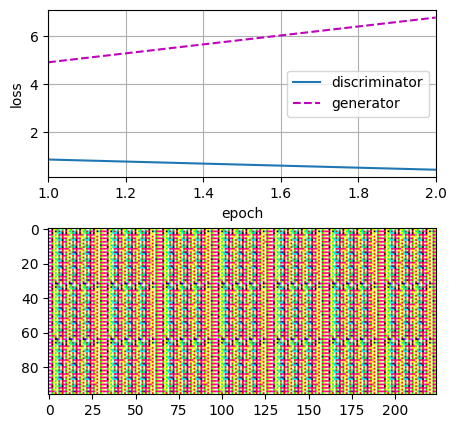

In [7]:
latent_dim, lr, num_epochs = 120, 0.05, 2 #3 min
train(net_D, net_G, data_iter, num_epochs, lr, latent_dim)

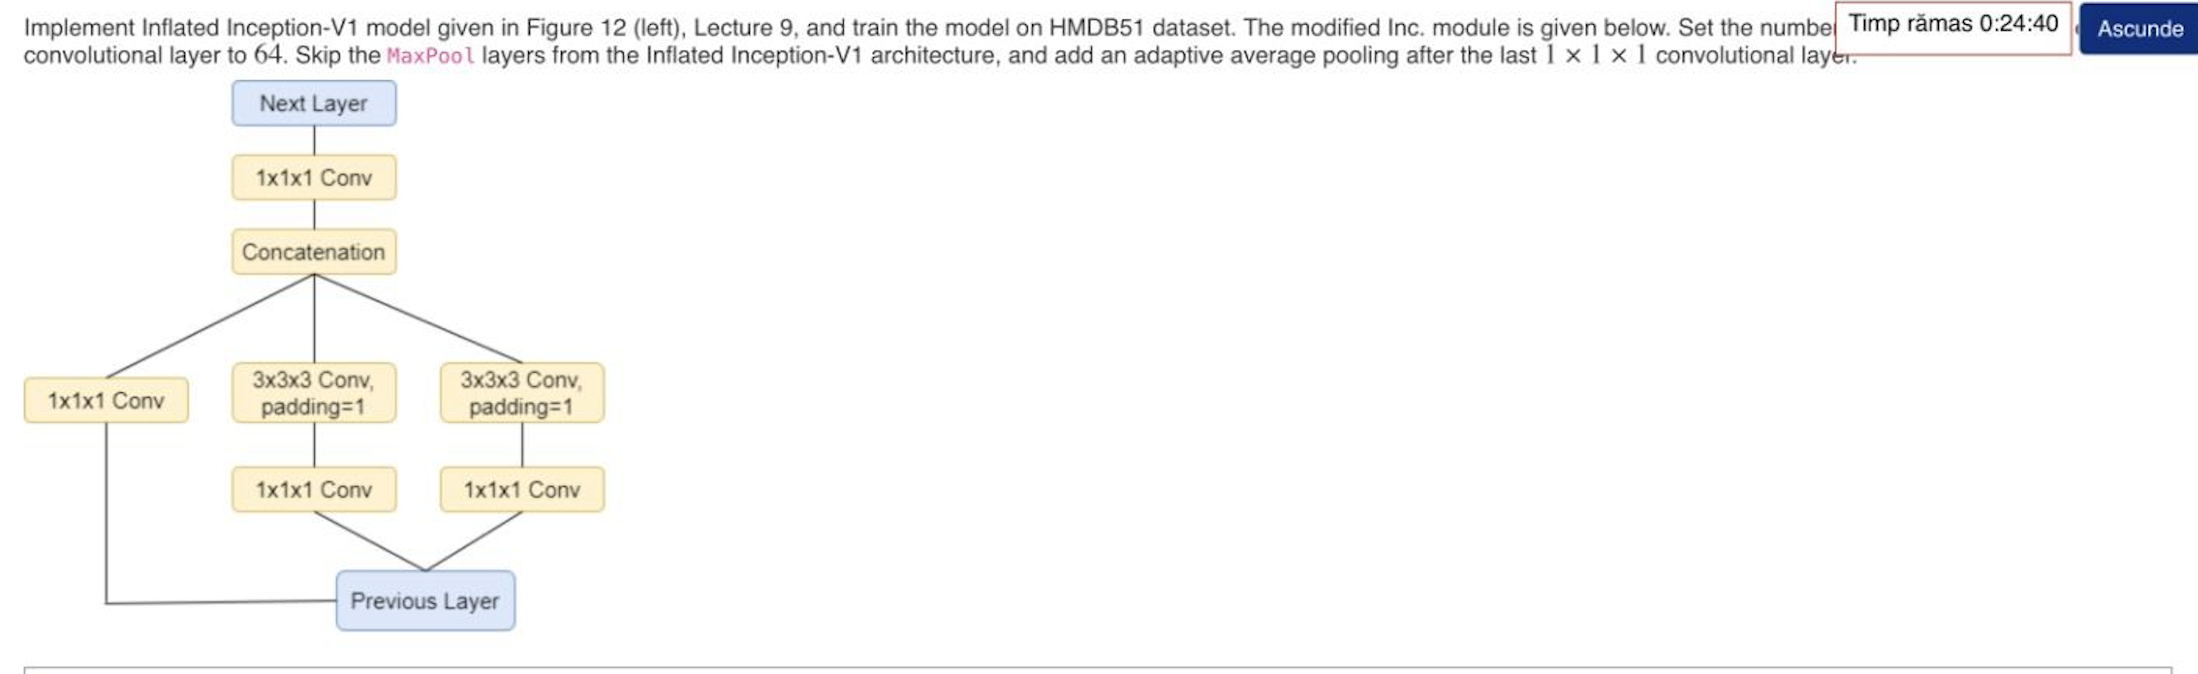

In [ ]:
!pip install av

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import random_split, DataLoader
from torch.optim.lr_scheduler import StepLR
import torchvision
from torchvision.models.video import r3d_18
from torchvision import transforms
import os
import warnings

torch.manual_seed(42);

warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!mkdir -p video_data test_train_splits
!unrar e 'drive/MyDrive/test_train_splits.rar' test_train_splits # Provide the proper path location
!unrar e 'drive/MyDrive/hmdb51_org.rar' video_data # Provide the proper path location

for files in os.listdir('video_data'):
    foldername = files.split('.')[0]
    os.system("mkdir -p video_data/" + foldername)
    os.system("unrar e video_data/"+ files + " video_data/" + foldername)
!rm video_data/*.rar

In [ ]:
val_split = 0.05 #3 min
num_frames = 16
clip_steps = 50
num_workers = 8
bs = 4

train_tfms = torchvision.transforms.Compose([
                                 transforms.Lambda(lambda x: x.permute(3, 0, 1, 2).to(torch.float32) / 255.),
                                 transforms.Resize((128, 171)),
                                 transforms.RandomHorizontalFlip(),
                                 transforms.RandomCrop((112, 112))
                               ])
test_tfms = torchvision.transforms.Compose([
                                             transforms.Lambda(lambda x: x.permute(3, 0, 1, 2).to(torch.float32) / 255.),
                                             transforms.Resize((128, 171)),
                                             transforms.CenterCrop((112, 112))
                                             ])

hmdb51_train = torchvision.datasets.HMDB51('video_data/', 'test_train_splits/', num_frames,
                                                step_between_clips=clip_steps, fold=1, train=True,
                                                transform=train_tfms, num_workers=num_workers)

hmdb51_test = torchvision.datasets.HMDB51('video_data/', 'test_train_splits/', num_frames,
                                                step_between_clips=clip_steps, fold=1, train=False,
                                                transform=test_tfms, num_workers=num_workers)


total_train_samples = len(hmdb51_train)
total_val_samples = round(val_split * total_train_samples)

hmdb51_train_v1, hmdb51_val_v1 = random_split(hmdb51_train, [total_train_samples - total_val_samples, total_val_samples])

train_loader = DataLoader(hmdb51_train_v1, batch_size=bs, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(hmdb51_val_v1, batch_size=bs, shuffle=True, num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(hmdb51_test, batch_size=bs, shuffle=False, num_workers=num_workers, pin_memory=True)

print(f"number of train samples {total_train_samples - total_val_samples}")
print(f"number of validation samples {total_val_samples}")
print(f"number of test samples {len(hmdb51_test)}")

In [ ]:
class InceptionModule(nn.Module):
  def __init__(self,in_channels,out_channels=64):
      super(InceptionModule, self).__init__()

      self.branch1 = nn.Sequential(
          nn.Conv3d(in_channels, 32, kernel_size=(1,1,1)))

      self.branch2 = nn.Sequential(
          nn.Conv3d(in_channels, 32, kernel_size=(1,1,1)),
          nn.Conv3d(32, 32, kernel_size=(3,3,3), padding=(1,1,1)))

      self.branch3 = nn.Sequential(
          nn.Conv3d(in_channels, 32, kernel_size=(1,1,1)),
          nn.Conv3d(32, 32, kernel_size=(3,3,3), padding=(1,1,1)))

      self.after_care=nn.Sequential(
          nn.Conv3d(96, out_channels, kernel_size=(1,1,1)))

  def forward(self, x):
      b1=self.branch1(x)
      b2=self.branch2(x)
      b3=self.branch3(x)

      x=torch.cat((b1,b2,b3),dim=1)
      x=self.after_care(x)
      return x

In [ ]:
class InflatedInceptionV1(nn.Module):
    def __init__(self, num_classes=51, in_channels=3):
        super(InflatedInceptionV1, self).__init__()


        self.conv1 = nn.Sequential(
            nn.Conv3d(in_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True)
        )

        self.conv2 = nn.Sequential(
            nn.Conv3d(64, 64, kernel_size=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True)
        )


        self.conv3 = nn.Sequential(
            nn.Conv3d(64, 192, kernel_size=3, padding=1),
            nn.BatchNorm3d(192),
            nn.ReLU(inplace=True)
        )


        self.inc1 = InceptionModule(192, 64)
        self.inc2 = InceptionModule(64, 64)

        self.inc3 = InceptionModule(64, 64)
        self.inc4 = InceptionModule(64, 64)
        self.inc5 = InceptionModule(64, 64)
        self.inc6 = InceptionModule(64, 64)
        self.inc7 = InceptionModule(64, 64)

        self.inc8 = InceptionModule(64, 64)
        self.inc9 = InceptionModule(64, 64)


        self.final_conv = nn.Conv3d(64, num_classes, kernel_size=1)


        self.avg_pool = nn.AdaptiveAvgPool3d((1, 1, 1))

    def forward(self, x):

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)


        x = self.inc1(x)
        x = self.inc2(x)
        x = self.inc3(x)
        x = self.inc4(x)
        x = self.inc5(x)
        x = self.inc6(x)
        x = self.inc7(x)
        x = self.inc8(x)
        x = self.inc9(x)


        x = self.final_conv(x)
        x = self.avg_pool(x)

        x = torch.flatten(x, 1)
        return x




In [ ]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')